In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dt = pd.read_csv(r"C:\Users\Rutik Bhendarkar\House Price Prediction\bengaluru_house_prices.csv")
dt

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [3]:
dt.shape

(13320, 9)

In [4]:
dt.groupby('area_type')['area_type'].agg('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [5]:
dt1 = dt.drop(['area_type','society','balcony','availability'], axis='columns')
dt1

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [6]:
dt1.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [7]:
# Fill location (categorical)
dt1['location'] = dt1['location'].fillna(dt1['location'].mode()[0])

# Calculate median from extracted numeric values (temporary conversion)
median_size = dt1['size'].astype(str).str.extract('(\d+)').astype(float).median()[0]

# Fill missing values in size (keep original format)
dt1['size'] = dt1['size'].fillna(str(int(median_size)))

# Create bhk column (numeric)
dt1['bhk'] = dt1['size'].astype(str).str.extract('(\d+)').astype(int)

# Fill bath
dt1['bath'] = dt1['bath'].fillna(dt1['bath'].median())

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Rutik Bhendarkar\AppData\Local\Temp\ipykernel_9456\1524561358.py:5: SyntaxWarning: invalid escape sequence '\d'
  median_size = dt1['size'].astype(str).str.extract('(\d+)').astype(float).median()[0]
C:\Users\Rutik Bhendarkar\AppData\Local\Temp\ipykernel_9456\1524561358.py:11: SyntaxWarning: invalid escape sequence '\d'
  dt1['bhk'] = dt1['size'].astype(str).str.extract('(\d+)').astype(int)


In [8]:
dt1.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
bhk           0
dtype: int64

In [9]:
dt1.shape

(13320, 6)

In [10]:
dt1['size'].unique()

<ArrowStringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',      '4 BHK',  '6 Bedroom',
  '3 Bedroom',      '1 BHK',       '1 RK',  '1 Bedroom',  '8 Bedroom',
  '2 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',          '3',  '9 Bedroom',
     '27 BHK', '10 Bedroom', '11 Bedroom',     '10 BHK',     '19 BHK',
     '16 BHK', '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',
     '13 BHK', '18 Bedroom']
Length: 32, dtype: str

In [11]:
dt1

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2
...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00,5
13316,Richards Town,4 BHK,3600,5.0,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00,2
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00,4


In [12]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [13]:
dt1[~dt1['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
56,Devanahalli,4 Bedroom,3010 - 3410,2.0,192.000,4
81,Hennur Road,4 Bedroom,2957 - 3450,2.0,224.500,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
224,Devanahalli,3 BHK,1520 - 1740,2.0,74.820,3
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2


In [14]:
def conver_sqft_to_num(x):
    token= x.split('-')
    if len(token)==2:
        return (float(token[0])+float(token[1]))/2
    try:
        return float(x)
    except:
        return None
        
    

In [15]:
conver_sqft_to_num('2166')

2166.0

In [16]:
conver_sqft_to_num('1015 - 1540')

1277.5

In [17]:
conver_sqft_to_num('34.46Sq. Meter')

In [18]:
dt2 = dt1.copy()
dt2['total_sqft'] = dt2['total_sqft'].apply(conver_sqft_to_num)
dt.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [19]:
dt2["price_per_sqft"] = dt2['price']*100000/dt2['total_sqft']
dt2

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926
13316,Richards Town,4 BHK,3600.0,5.0,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136
13318,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407.336319


In [20]:
dt2.location = dt2.location.apply(lambda x:x.strip())
location_stats = dt2.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats

location
Whitefield               542
Sarjapur  Road           399
Electronic City          304
Kanakpura Road           273
Thanisandra              237
                        ... 
1 Giri Nagar               1
Kanakapura Road,           1
Kanakapura main  Road      1
Karnataka Shabarimala      1
whitefiled                 1
Name: location, Length: 1294, dtype: int64

In [21]:
len(location_stats[location_stats<=10])

1053

In [22]:
location_stats_less_than_10 = location_stats[location_stats<=10]
location_stats_less_than_10

location
Sadashiva Nagar          10
Nagappa Reddy Layout     10
Nagadevanahalli          10
Dodsworth Layout         10
1st Block Koramangala    10
                         ..
1 Giri Nagar              1
Kanakapura Road,          1
Kanakapura main  Road     1
Karnataka Shabarimala     1
whitefiled                1
Name: location, Length: 1053, dtype: int64

In [23]:
len(dt2.location.unique())

1294

In [24]:
dt2.location = dt2.location.apply(lambda x:'other' if x in location_stats_less_than_10 else x)
len(dt2.location.unique())

242

In [25]:
dt2

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926
13316,other,4 BHK,3600.0,5.0,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136
13318,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407.336319


In [26]:
dt2[dt2.total_sqft/dt2.bhk<300].head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,other,3 Bedroom,500.0,3.0,100.0,3,20000.000000


In [27]:
dt3 = dt2[~(dt2.total_sqft/dt2.bhk<300)]
dt3.shape

(12576, 7)

In [28]:
dt3.price_per_sqft.describe()

count     12530.000000
mean       6303.979357
std        4162.237981
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [29]:
def remove_pps_outliers(dt):
    df_out = pd.DataFrame()
    
    for key, subdf in dt.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        
        reduced_df = subdf[
            (subdf.price_per_sqft > (m - st)) &
            (subdf.price_per_sqft <= (m + st))
        ]
        
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    
    return df_out

In [30]:
dt4 = remove_pps_outliers(dt3)
dt4.shape

(10301, 7)

In [31]:
def plot_scatter_chart(df, location):
    bhk2 = dt2[(dt2.location == location) & (dt2.bhk == 2)]
    bhk3 = dt2[(dt2.location == location) & (dt2.bhk == 3)]
    
    plt.figure(figsize=(15, 10))
    
    plt.scatter(bhk2.total_sqft, bhk2.price_per_sqft, 
                color='blue', label='2 BHK', s=50)
    
    plt.scatter(bhk3.total_sqft, bhk3.price_per_sqft, 
                marker='+', color='green', label='3 BHK', s=50)
    
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price Per Square Feet")
    plt.title(location)
    plt.legend()

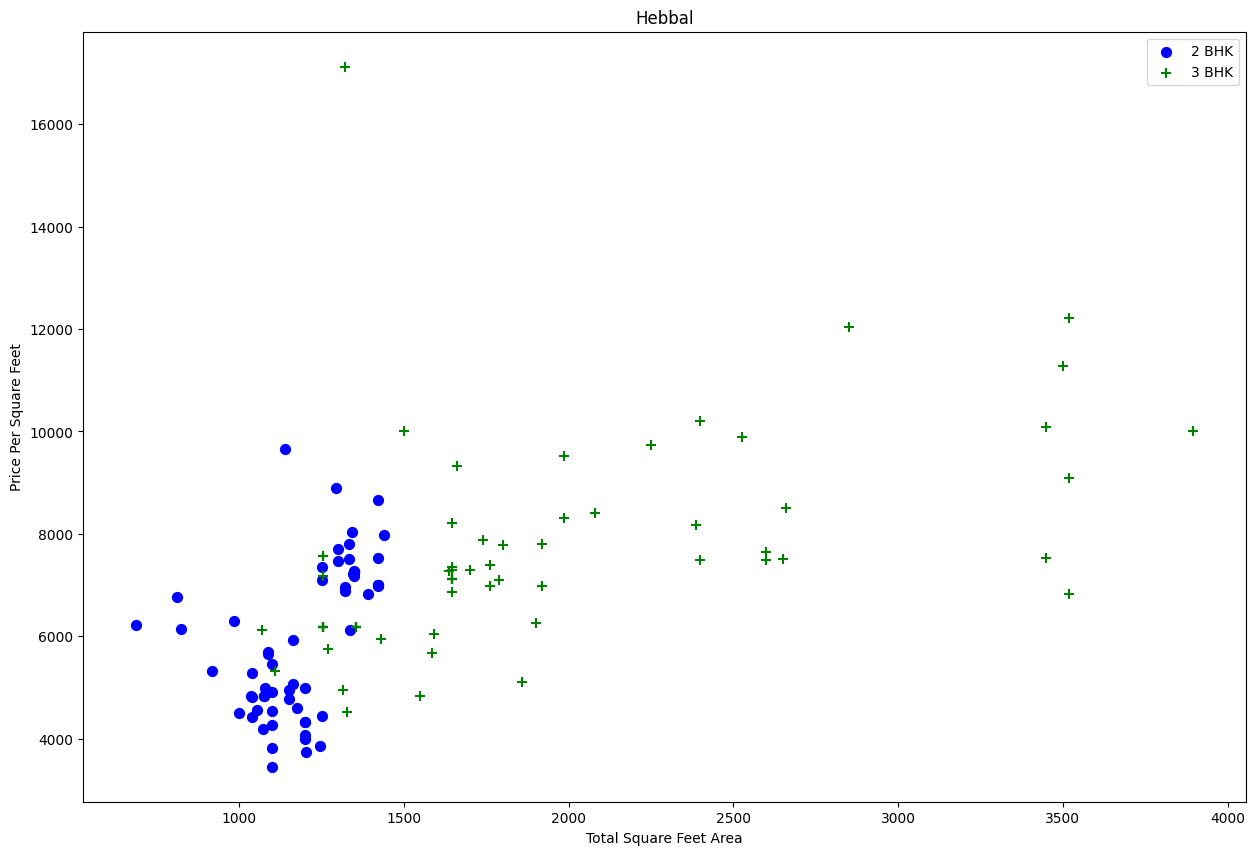

In [32]:
plot_scatter_chart(dt4,"Hebbal")

In [33]:
def remove_bhk_outlier(dt):
    exclude_indices = np.array([])
    
    for location, location_dt in dt.groupby('location'):
        bhk_stats = {}
        
        for bhk, bhk_dt in location_dt.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_dt.price_per_sqft),
                'std': np.std(bhk_dt.price_per_sqft),
                'count': bhk_dt.shape[0]
            }
        
        for bhk, bhk_dt in location_dt.groupby('bhk'):
            stats = bhk_stats.get(bhk - 1)
            
            if stats and stats['count'] > 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_dt[bhk_dt.price_per_sqft < stats['mean']].index.values
                )
    
    return dt.drop(exclude_indices, axis='index')

dt4 = remove_bhk_outlier(dt3)
dt4.shape

(8735, 7)

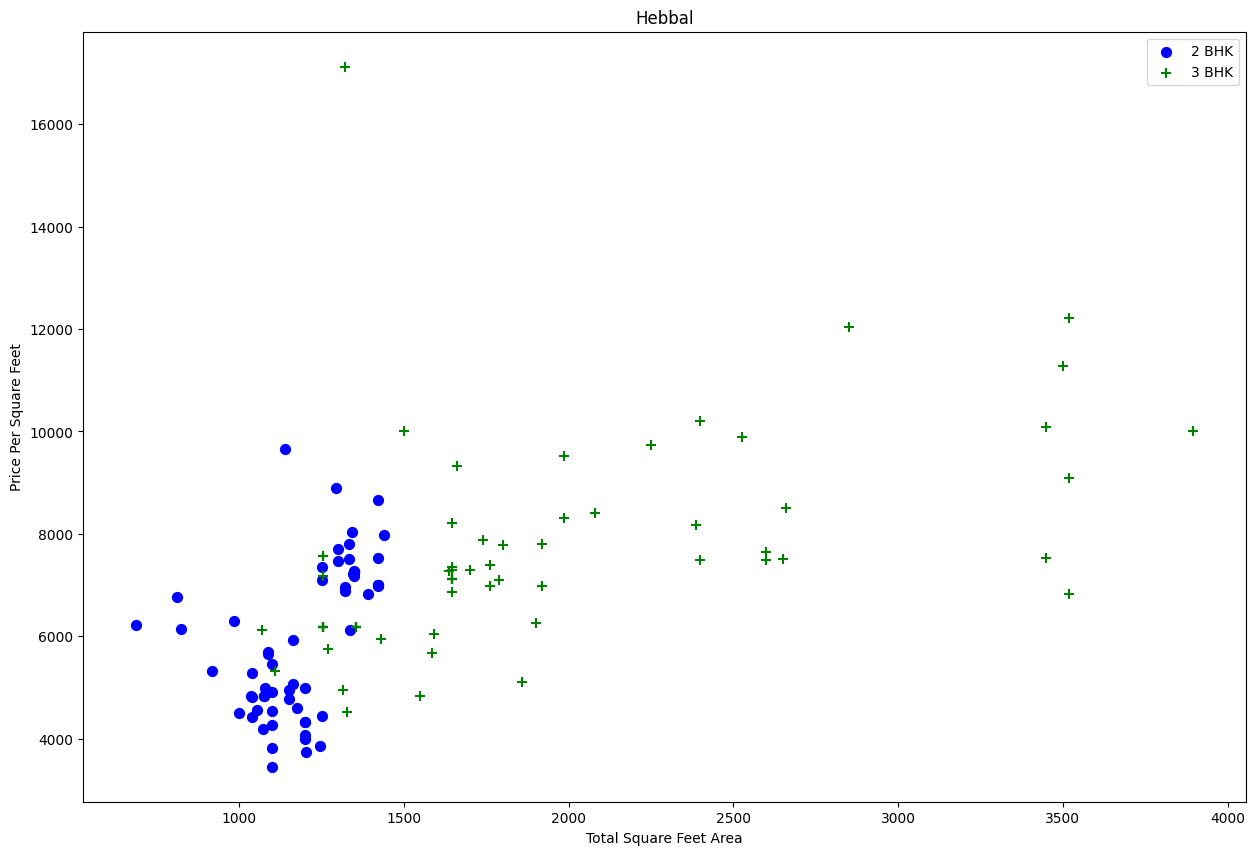

In [34]:
plot_scatter_chart(dt4,"Hebbal")

<Figure size 2000x1000 with 0 Axes>

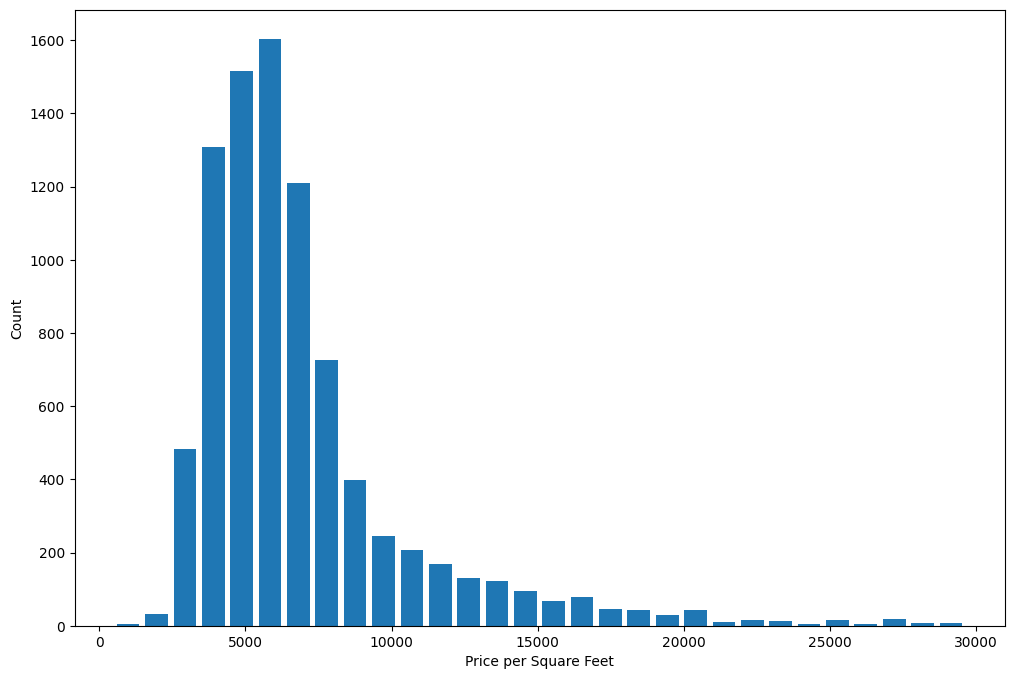

In [35]:
import matplotlib
plt.figure(figsize=(20,10))
plt.figure(figsize=(12,8))

# Limit range (remove extreme values from visualization only)
data = dt4[dt4.price_per_sqft < 30000]

plt.hist(data.price_per_sqft, bins=30, rwidth=0.8)

plt.xlabel("Price per Square Feet")
plt.ylabel("Count")

# Set clean ticks
plt.xticks(range(0, 30001, 5000))

plt.show()

In [36]:
dt4.bath.unique()

array([ 2.,  3.,  4.,  5.,  1.,  8.,  6.,  7.,  9., 14., 16., 10., 12.,
       13.])

In [37]:
dt4[dt4.bath>10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
1078,other,9 Bedroom,3300.0,14.0,500.0,9,15151.515152
3609,other,16 BHK,10000.0,16.0,550.0,16,5500.000000
7979,other,11 BHK,6000.0,12.0,150.0,11,2500.000000
8636,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
9935,other,13 BHK,5425.0,13.0,275.0,13,5069.124424
13067,other,10 Bedroom,7150.0,13.0,3600.0,10,50349.650350


Text(0, 0.5, 'Count')

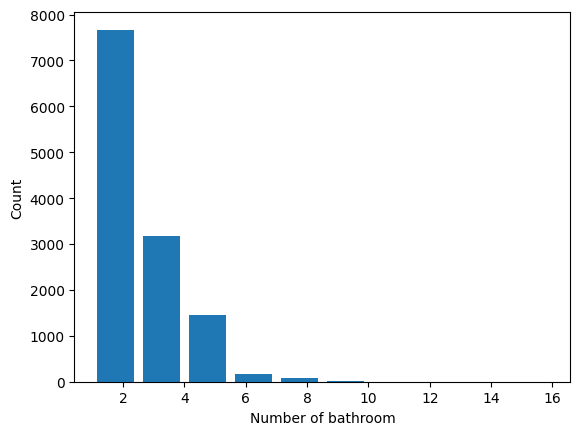

In [38]:
plt.hist(dt3.bath, rwidth=0.8)
plt.xlabel("Number of bathroom")
plt.ylabel("Count")

In [39]:
dt4[dt4.bath>dt4.bhk+2]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
1078,other,9 Bedroom,3300.0,14.0,500.0,9,15151.515152
6838,Rajaji Nagar,5 BHK,7500.0,8.0,1700.0,5,22666.666667
7709,Chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.032520
9974,other,3 Bedroom,2400.0,6.0,775.0,3,32291.666667
11366,Nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.571429
12103,Thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.034330
12443,other,4 Bedroom,4350.0,8.0,2600.0,4,59770.114943
13067,other,10 Bedroom,7150.0,13.0,3600.0,10,50349.650350


In [40]:
dt9 =dt4[dt4.bath<dt4.bhk+2]
dt9.shape

(8605, 7)

In [41]:
dt10 = dt9.drop(['size','price_per_sqft'], axis='columns')
dt10.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2
6,Old Airport Road,2732.0,4.0,204.00,4


In [42]:
dummies=pd.get_dummies(dt10.location)

In [43]:
dt11 =pd.concat([dt10,dummies.drop('other',axis='columns')],axis='columns')
dt11.head()

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,Electronic City Phase II,1056.0,2.0,39.07,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Uttarahalli,1440.0,2.0,62.00,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Lingadheeranahalli,1521.0,3.0,95.00,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Kothanur,1200.0,2.0,51.00,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,Old Airport Road,2732.0,4.0,204.00,4,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [44]:
dt12=dt11.drop('location',axis='columns')

In [45]:
dt12.shape

(8605, 245)

In [46]:
x = dt12.drop('price',axis='columns')
y = dt12.price
y = y.fillna(y.mean())
y

0         39.07
2         62.00
3         95.00
4         51.00
6        204.00
          ...  
13314    112.00
13316    400.00
13317     60.00
13318    488.00
13319     17.00
Name: price, Length: 8605, dtype: float64

In [47]:
x = x.fillna(x.median(numeric_only=True))
x

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1056.0,2.0,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1440.0,2.0,3,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,3,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,2.0,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,2732.0,4.0,4,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13314,1715.0,3.0,3,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13316,3600.0,5.0,4,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13317,1141.0,2.0,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13318,4689.0,4.0,4,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [48]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, ShuffleSplit
import pandas as pd

In [49]:
def find_best_model(x, y):
    
    algos = {
        'linear_regression': {
            'model': LinearRegression(),
            'params': {}
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1, 2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['squared_error', 'friedman_mse'],
                'splitter': ['best', 'random']
            }
        },
        'random_forest': {
            'model': RandomForestRegressor(),
            'params': {
                'n_estimators': [50, 100],
                'max_depth': [None, 10, 20]
            }
        },
        'xgboost': {
            'model': XGBRegressor(),
            'params': {
                'n_estimators': [50, 100],
                'learning_rate': [0.05, 0.1],
                'max_depth': [3, 5]
            }
        }
    }

    scores = []
    best_model = None
    best_score = -1

    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv=cv, scoring='r2')
        gs.fit(x, y)

        score = gs.best_score_

        scores.append({
            'model': algo_name,
            'best_score': score,
            'best_params': gs.best_params_
        })

        # Track best model
        if score > best_score:
            best_score = score
            best_model = gs.best_estimator_

    print(pd.DataFrame(scores))

    return best_model

In [52]:
def predict_price(location, sqft, bath, bhk):

    loc_index = np.where(x.columns == location)[0]

    input_data = np.zeros(len(x.columns))

    input_data[0] = sqft
    input_data[1] = bath
    input_data[2] = bhk

    if len(loc_index) > 0:
        input_data[loc_index[0]] = 1

    return best_model.predict([input_data])[0]

In [50]:
best_model = find_best_model(x, y)

               model  best_score  \
0  linear_regression    0.565866   
1              lasso    0.505515   
2      decision_tree    0.440001   
3      random_forest    0.620577   
4            xgboost    0.633039   

                                         best_params  
0                                                 {}  
1                {'alpha': 1, 'selection': 'cyclic'}  
2  {'criterion': 'squared_error', 'splitter': 'ra...  
3             {'max_depth': 10, 'n_estimators': 100}  
4  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...  


In [54]:
print("Best Model Used:", best_model)

Best Model Used: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


In [53]:
predict_price('1st Phase JP Nagar', 1000, 2, 2)

51.85968

In [57]:
import pickle

# Save model
with open("banglore_home_price_model.pickle", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved successfully!")

Model saved successfully!


In [56]:
import json

columns = {
    "data_columns": [col.lower() for col in x.columns]
}

with open("columns.json", "w") as f:
    json.dump(columns, f)

print("Columns saved successfully!")

Columns saved successfully!
